In [1]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../MERS/')

## 1. Generate TOD with chromatic Sinc^2 beam and ptsrc

In [2]:
from astropy.coordinates import EarthLocation, AltAz, SkyCoord
from astropy.time import Time
import astropy.units as u
import healpy as hp

# === JBO site ===
lat = 53.23625  # degrees
lon = -2.30744  # degrees
location = EarthLocation(lat=lat*u.deg, lon=lon*u.deg)

# === Generate obs_time list（UTC）===
# From 2024-10-01 22:00 to 2024-10-02 05:00，every "delta_minutes" minute
start_time = Time('2024-10-01 22:00:00', scale='utc', location=location)
end_time   = Time('2024-10-02 05:00:00', scale='utc', location=location)
delta_minutes = 2

# Construct the time sequence
times = start_time + np.arange(0, (end_time - start_time).to_value('min') + delta_minutes, delta_minutes) * u.min

# === Calculate the corresponding LSTs ===
lst_array = times.sidereal_time('mean', longitude=lon*u.deg)

# === Constants ===
Nside = 128  # HEALPix resolution
lat = 53.23625  # JBO latitude in degrees

# === Step 1: LSTs → (RA, Dec) for zenith ===
# Dec of zenith = latitude
dec_zenith = lat * u.deg
ra_zeniths = lst_array.to(u.deg)  # LST is the RA of the zenith

# === Step 2: Convert to Galactic coordinates ===
skycoords_eq = SkyCoord(ra=ra_zeniths, dec=dec_zenith, frame='icrs')
skycoords_gal = skycoords_eq.galactic

# === Step 3: Convert to HEALPix pixel indices ===
# Use vector representation to feed into healpy
vecs = skycoords_gal.represent_as('cartesian').get_xyz().value  # shape: (3, N)
pix_indices = hp.vec2pix(Nside, vecs[0], vecs[1], vecs[2])

In [3]:
from beam_model import Chromatic_Sinc_Squared

# Set up the frequency list: [50, 100] MHz
freq_list = np.linspace(50., 100., 101)
Nfreq = len(freq_list)

def fwhm_function(nu_mhz, params):
    return params["K"] / nu_mhz

fwhm_func_params = {"K": 1000}

Sinc_ch_beam = Chromatic_Sinc_Squared(freq_list, fwhm_function, fwhm_func_params, nside=Nside)
Sinc_ch_beam.get_beam_l()
Sinc_ch_bl0 = Sinc_ch_beam.bl_list
Sinc_ch_bl = [ B_l0 * np.sqrt(4 * np.pi / (2 * np.arange(len(B_l0)) + 1)) for B_l0 in Sinc_ch_bl0 ]


## Generate sky TOD

from fg_model import CNN_PL_sky, ptsrc_powerlaw
# Point source model initialization
ptsrc_model = ptsrc_powerlaw(nside=Nside)

def sky_TOD(beam_window=None, add_ptsrc=True, pix_indices=pix_indices):
    """
    Generate sky time-ordered data (TOD) for the given beam window function.
    
    Parameters:
    beam_window: list of ndarray
        Beam window functions for each frequency channel. Each element should be an array of shape (lmax+1,).
        If None, no beam is applied.
    add_ptsrc: bool
        Whether to include point sources in the sky model.
    
    Returns:
    sky_TOD: ndarray
        Time-ordered data of the sky, shape (Ntime, Nfreq).
    """

    # Diffuse + ptsrc sky model
    diffuse_sky, pivot_specidx_map = CNN_PL_sky(freq_list, beam_transfer=beam_window, nside=Nside, return_spec_index=True)
    
    if add_ptsrc:
        ptsrc_sky = ptsrc_model(freq_list, beam_transfer=beam_window)
        combined_sky = diffuse_sky + ptsrc_sky
    else:
        combined_sky = diffuse_sky

    if pix_indices is None: # Return full-sky map if no pixel indices are provided
        return combined_sky, pivot_specidx_map
    
    sky_TOD = combined_sky[pix_indices, :]  # shape: (Ntime, Nfreq)
    piv_spec_ind_TOD = pivot_specidx_map[pix_indices]  
    
    return sky_TOD, piv_spec_ind_TOD


sky_TOD_Sinc_ch, pivot_specind_TOD = sky_TOD(beam_window=Sinc_ch_bl)


## 2. Beam chromaticity methods

### 2.1 BCF method

In [4]:
def sky_map(ind,add_ptsrc=True):
    """
    Generate sky time-ordered  data (TOD) for the given beam window function.
    
    Parameters:
    add_ptsrc: bool
        Whether to include point sources in the sky model.
    
    Returns:
    sky_TOD: ndarray
        Time-ordered data of the sky, shape (Ntime, Nfreq).
    """

    # Diffuse + ptsrc sky model
    diffuse_sky, _ = CNN_PL_sky(freq_list, nside=Nside, return_spec_index=True)
    
    if add_ptsrc:
        ptsrc_sky = ptsrc_model(freq_list)
        combined_sky = diffuse_sky + ptsrc_sky
    else:
        combined_sky = diffuse_sky

    return combined_sky[:,ind]

In [5]:
ref_map = sky_map(50,add_ptsrc=True)
print(ref_map.shape)

(196608,)


In [6]:
# BCF
ref_beam_window = Sinc_ch_beam.bl_list[50]
Sinc_BCF_cube = np.array(Sinc_ch_beam.generate_BCF(ref_map, ref_beam_window))

### 2.2 SVD beam

In [7]:
# SVD of the beam
Sinc_U, Sinc_S, Sinc_Vh = Sinc_ch_beam.generate_SVD_beams()


/Users/zzhang/Workspace/MERS/notebooks/../MERS/beam_model.py:208: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


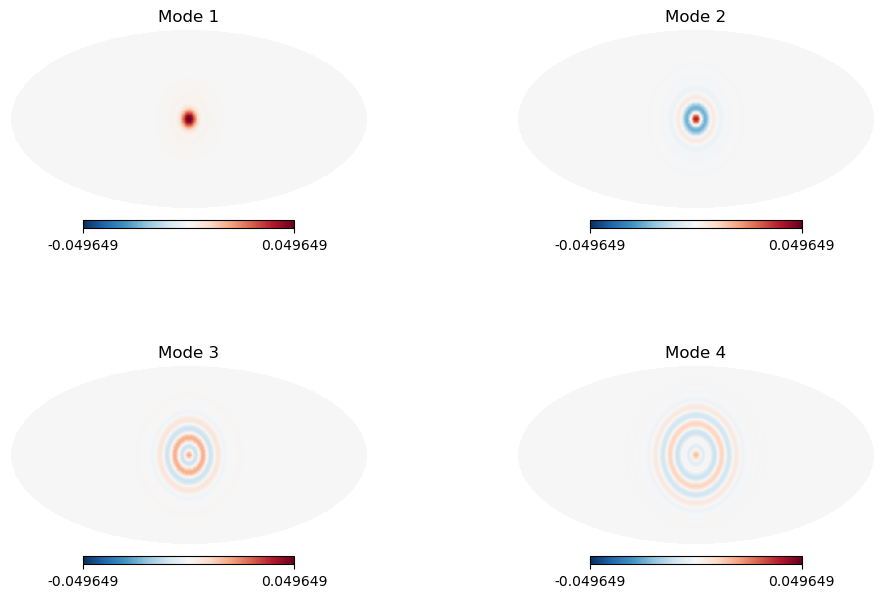

In [8]:
from beam_model import plot_svd_beam_modes

plot_svd_beam_modes(Sinc_Vh, nest=False)

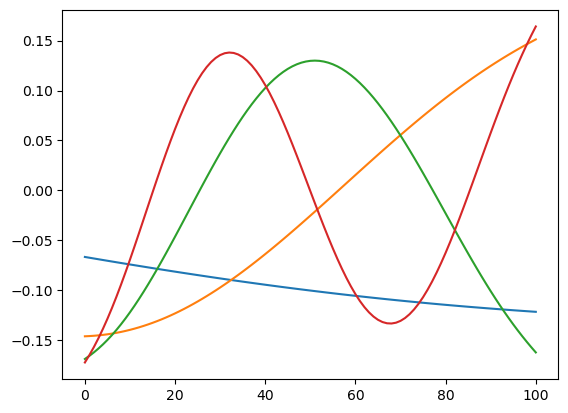

In [13]:
# First few SVD beam modesin frequency space

plt.plot(Sinc_U[:, :4])

### 2.3 Fitting Sky TOD (foregrounds) with beam chromaticity corrections 

In [9]:
from SEDfitting import fit_fg_cube

max_order = 6

chSinc_coeffs, chSinc_loss, chSinc_resi = fit_fg_cube(
    sky_TOD_Sinc_ch, 
    pivot_specind_TOD, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=None, 
    BCF=None
)

chSinc_coeffs_BCF, chSinc_loss_BCF, chSinc_resi_BCF = fit_fg_cube(
    sky_TOD_Sinc_ch, 
    pivot_specind_TOD, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=None, 
    BCF=Sinc_BCF_cube
)

n_beam = 2  # Number of SVD beam modes to use
chSinc_coeffs_SVD_2, chSinc_loss_SVD_2, chSinc_resi_SVD_2 = fit_fg_cube(
    sky_TOD_Sinc_ch, 
    pivot_specind_TOD, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=Sinc_U[:, :n_beam], 
    BCF=None
)

n_beam = 3
chSinc_coeffs_SVD_3, chSinc_loss_SVD_3, chSinc_resi_SVD_3 = fit_fg_cube(
    sky_TOD_Sinc_ch, 
    pivot_specind_TOD, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=Sinc_U[:, :n_beam], 
    BCF=None
)

n_beam = 6
chSinc_coeffs_SVD_6, chSinc_loss_SVD_6, chSinc_resi_SVD_6 = fit_fg_cube(
    sky_TOD_Sinc_ch, 
    pivot_specind_TOD, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=Sinc_U[:, :n_beam], 
    BCF=None
)


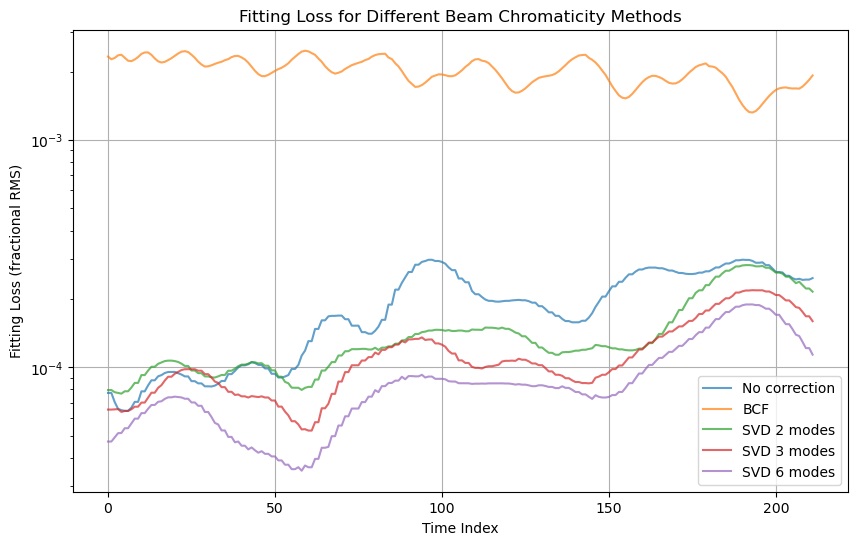

In [10]:
# Visualize the fitting loss for different beam chromaticity methods
plt.figure(figsize=(10,6))
plt.plot(chSinc_loss, label='No correction', alpha=0.7)
plt.plot(chSinc_loss_BCF, label='BCF', alpha=0.7)
plt.plot(chSinc_loss_SVD_2, label='SVD 2 modes', alpha=0.7)
plt.plot(chSinc_loss_SVD_3, label='SVD 3 modes', alpha=0.7)
plt.plot(chSinc_loss_SVD_6, label='SVD 6 modes', alpha=0.7)
plt.xlabel('Time Index')
plt.ylabel('Fitting Loss (fractional RMS)')
plt.yscale('log')
plt.legend()
plt.title('Fitting Loss for Different Beam Chromaticity Methods')
plt.grid()
plt.show()

## 3. Extract Global 21cm

Beam chromaticity is the biggest obstable..

We will try the SVD method to correct for the beam chromaticity..


In [15]:
from SEDfitting import Global_21cm_extraction

GS_object_50_100 = Global_21cm_extraction(freq_list)
true_signal = np.load('global_signal_50_100.npy')
true_signal *= 1e-3 # mK --> K

full_TOD = sky_TOD_Sinc_ch + true_signal[np.newaxis,:] + 2.732 

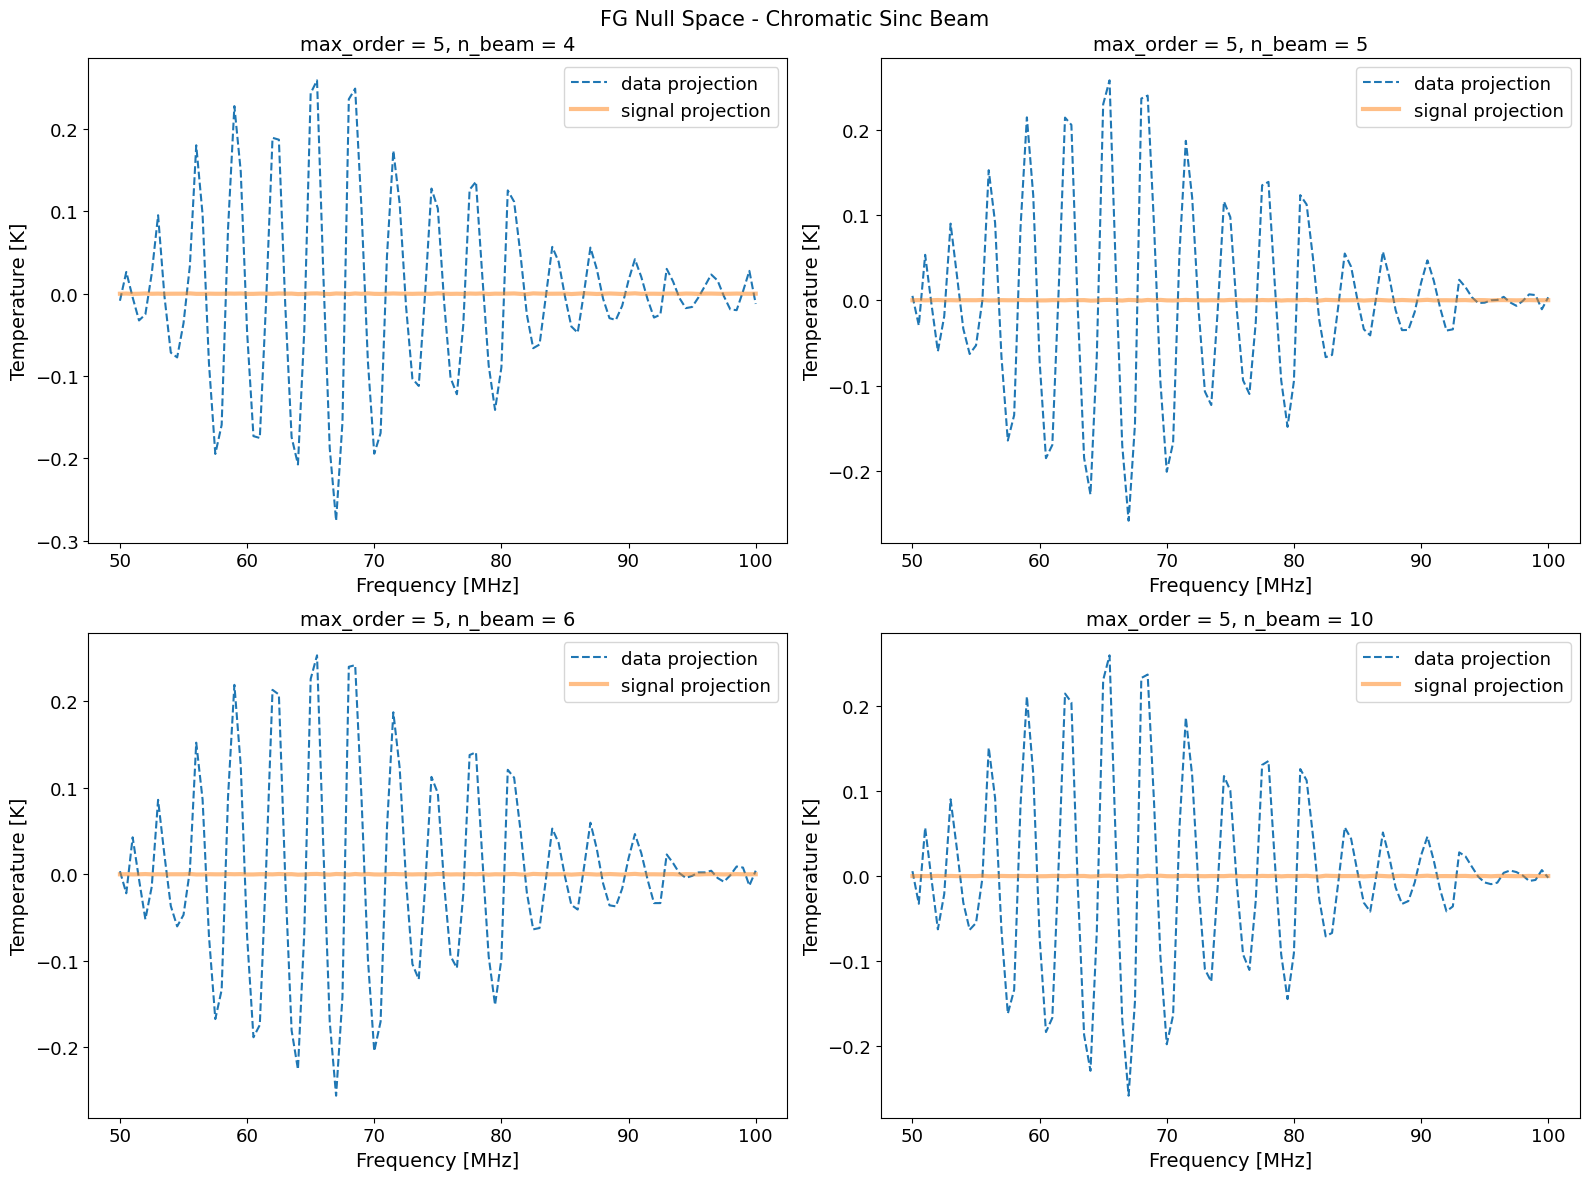

In [29]:
orders = [[5,5],[5,5]]
n_beams = [[4,5],[6,10]]
ind = 1

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

for i in range(2):
    for j in range(2):
        max_order = orders[i][j]
        n_beam = n_beams[i][j]
        data_projs, gs_projs =  GS_object_50_100.projection_in_fg_null_space(full_TOD, pivot_specind_TOD, max_order, true_signal, BCSVD=Sinc_U[:, :n_beam])
        ax = axs[i,j]
        ax.plot(freq_list, data_projs[ind], label='data projection', linestyle='--')
        ax.plot(freq_list, gs_projs[ind], label='signal projection', lw=3, alpha=0.5)
        ax.set_ylabel('Temperature [K]', fontsize=14)
        ax.set_xlabel('Frequency [MHz]', fontsize=14)
        ax.set_title('max_order = {}, n_beam = {}'.format(max_order, n_beam), fontsize=14)
        ax.legend(fontsize=13)
for ax in axs.flat:
    ax.tick_params(axis='both', which='major', labelsize=13)
plt.suptitle('FG Null Space - Chromatic Sinc Beam', fontsize=15)
plt.tight_layout()
plt.show()

### Yet another method

In [28]:
def beam_decompose_improved(B, r, n_iter=500, tol=1e-6, random_state=None):
    """
    Improved beam decomposition that properly handles the normalization constraint.
    Uses NMF followed by post-processing to enforce beam normalization.
    """
    # Ensure B is positive
    B = np.maximum(B, 1e-12)
    
    # Step 1: Use NMF with coordinate descent (usually more stable)
    model = NMF(n_components=r, init='nndsvda', max_iter=n_iter, tol=tol, 
                random_state=random_state, solver='cd', alpha_W=0.01, alpha_H=0.01)
    
    W = model.fit_transform(B)  # shape (Npix, r)
    H = model.components_       # shape (r, Nfreq)
    
    # Step 2: Post-process to enforce beam normalization
    # Current: B ≈ W @ H
    # Want: B ≈ sum_i c[i] * b[:,i] * s[:,i] where sum_n b[n,i] = 1
    
    # Normalize spatial components (beams)
    beam_sums = W.sum(axis=0)  # sum over pixels for each component
    beam_sums_safe = np.where(beam_sums < 1e-12, 1.0, beam_sums)
    
    b = W / beam_sums_safe[None, :]  # normalized beams
    
    # Absorb the normalization into the spectral components and amplitudes
    s_scaled = H.T * beam_sums_safe[None, :]  # shape (Nfreq, r)
    
    # Extract amplitudes as the mean of the spectral components
    c = np.mean(s_scaled, axis=0)
    c_safe = np.where(np.abs(c) < 1e-12, 1.0, c)
    
    # Final spectral components
    s = s_scaled / c_safe[None, :]
    
    return c, b, s

def test_improved_method():
    """Test the improved method"""
    rng = np.random.default_rng(42)
    Npix, Nfreq, r_true = 50, 30, 3

    # Ground truth: positive beams, normalized
    b_true = rng.random((Npix, r_true))
    b_true /= b_true.sum(axis=0, keepdims=True)

    # Ground truth: positive spectra
    s_true = rng.random((Nfreq, r_true)) + 0.5

    # Positive amplitudes
    c_true = rng.uniform(0.5, 2.0, size=r_true)

    # Construct positive B
    B = sum(c_true[i] * np.outer(b_true[:, i], s_true[:, i]) for i in range(r_true))
    
    # Add small positive noise
    noise = 1e-3 * rng.random(B.shape)
    B_noisy = B + noise

    print("Testing improved method:")
    c_imp, b_imp, s_imp = beam_decompose_improved(B_noisy, r=r_true, random_state=42)
    B_recon_imp = sum(c_imp[i] * np.outer(b_imp[:, i], s_imp[:, i]) for i in range(r_true))
    frob_err_imp = np.linalg.norm(B_noisy - B_recon_imp, 'fro') / np.linalg.norm(B_noisy, 'fro')
    
    print(f"  Relative Frobenius error: {frob_err_imp:.6f}")
    print(f"  Beam sums: {b_imp.sum(axis=0)}")
    print(f"  All positive? {np.all(b_imp >= 0) and np.all(s_imp >= 0)}")
    print(f"  Amplitudes: {c_imp}")

test_improved_method()

Testing improved method:
  Relative Frobenius error: 0.131876
  Beam sums: [1. 1. 1.]
  All positive? True
  Amplitudes: [3.43171624 0.23144373 0.20114402]
